In [1]:
from google.colab import files
uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("HR_comma_sep.csv")

In [5]:
print(df.head())
print(df.info())
print(df.describe())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

left
0    11428
1     3571
Name: count, dtype: int64


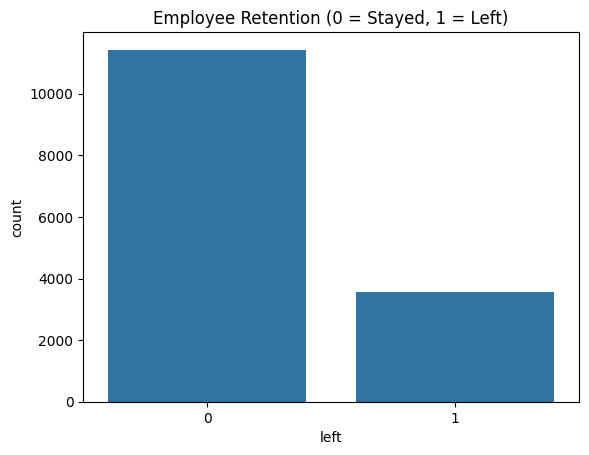

In [6]:
print(df['left'].value_counts())

sns.countplot(x='left', data=df)
plt.title("Employee Retention (0 = Stayed, 1 = Left)")
plt.show()

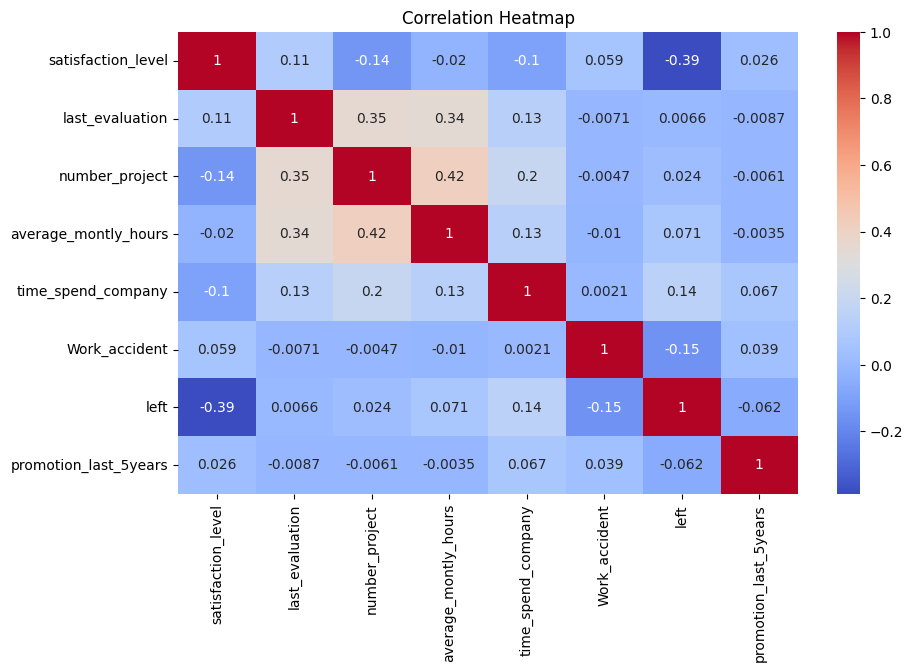

In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

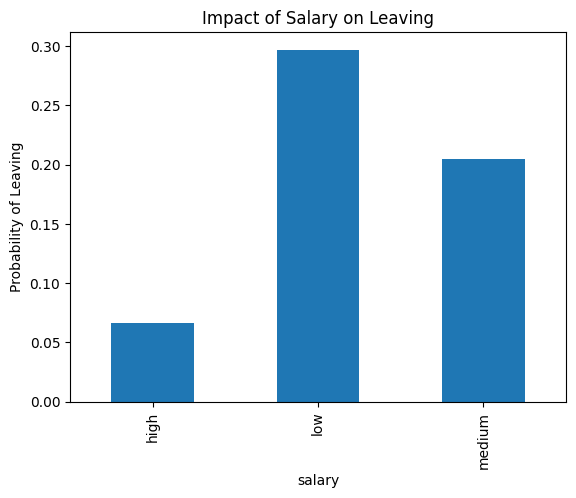

In [8]:
salary_retention = df.groupby('salary')['left'].mean()

salary_retention.plot(kind='bar')
plt.title("Impact of Salary on Leaving")
plt.ylabel("Probability of Leaving")
plt.show()

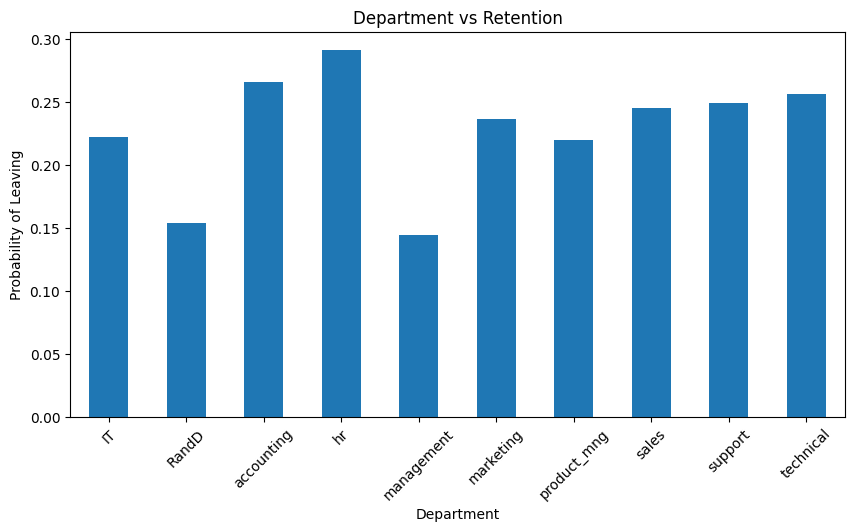

In [9]:
dept_retention = df.groupby('Department')['left'].mean()

dept_retention.plot(kind='bar', figsize=(10,5))
plt.title("Department vs Retention")
plt.ylabel("Probability of Leaving")
plt.xticks(rotation=45)
plt.show()

In [10]:
df = pd.get_dummies(df, columns=['salary', 'Department'], drop_first=True)

In [11]:
X = df.drop('left', axis=1)
y = df['left']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7823333333333333

Confusion Matrix:
[[2117  177]
 [ 476  230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      2294
           1       0.57      0.33      0.41       706

    accuracy                           0.78      3000
   macro avg       0.69      0.62      0.64      3000
weighted avg       0.76      0.78      0.76      3000



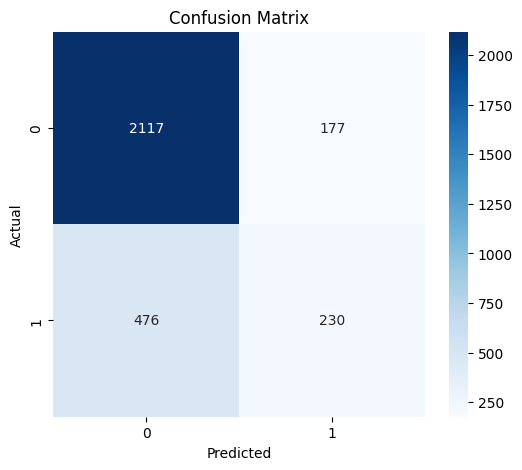

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()